### Problem Definition
- **What problem are we solving?** Classifying whether an airline ticket falls in the Economy or Business fare tier.
- **Why is this problem important?** Fare-tier classification underpins dynamic pricing and inventory allocation — airlines route pricing logic differently once a ticket is flagged Business vs Economy.
- **What type of ML problem is this?** Supervised Binary Classification.

### Dataset
- **What information does this dataset contain?** Route details, airline, duration, days until departure, and price.
- **What is the target?** class (Economy / Business).

In [18]:
import pandas as pd

df = pd.read_csv('./data/Flight_data.csv')

In [19]:
import pandas as pd

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df.isna().sum())
print(df[df.duplicated(keep=False)].count())

print('\nDuplicates')
df.drop_duplicates(inplace=True)
print(df[df.duplicated(keep=False)])

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Coun

           Count  Percentage (%)
class                           
Economy   206666       68.853551
Business   93487       31.146449


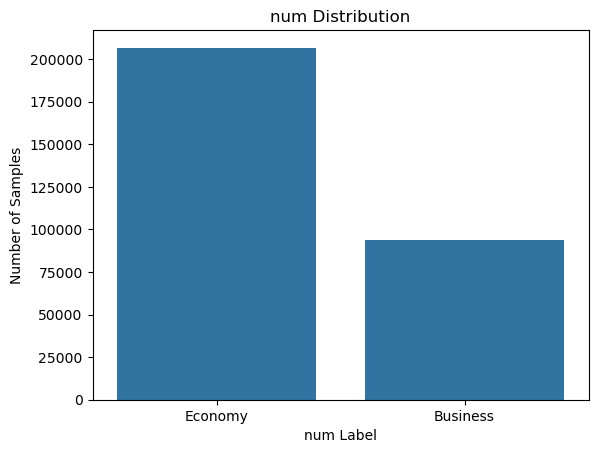

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['class'].value_counts()
percentages = df['class'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(imbalance_summary)

sns.countplot(x='class', data=df)
plt.title('num Distribution')
plt.xlabel('num Label')
plt.ylabel('Number of Samples')
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

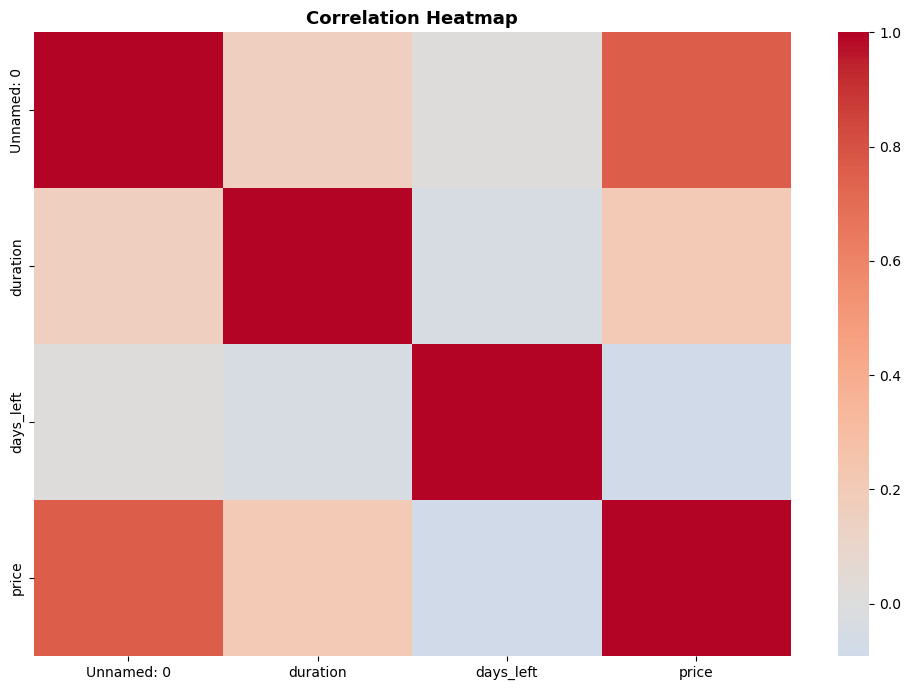

In [21]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include='number').corr(), fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [22]:
X = df.drop(columns=['Unnamed: 0', 'flight', 'class', 'price'])
y = df['class']

print(X.select_dtypes(include='number').skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)

duration     0.602899
days_left   -0.035464
dtype: float64


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

### Model Selection
- **Why choose this algorithm?** XGBoost (Extreme Gradient Boosting) builds trees sequentially, with each new tree correcting the errors of the previous ones. It is the undisputed king of structured/tabular data.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    # Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
from xgboost import XGBClassifier

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
random_forest_model = Pipeline([
    # Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
gradient_boost_model = Pipeline([
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
xgboost_model = Pipeline([
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=2
    ))
])

In [25]:
from tqdm.auto import tqdm

models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boost_model,
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    "XGBoost": xgboost_model,
}

for name, model in tqdm(models.items(), desc="Training Models"):
    model.fit(X_train, y_train.ravel())

Training Models:   0%|          | 0/3 [00:00<?, ?it/s]

### Evaluation
- **Why these metrics?** Accuracy alone can hide a model that just predicts the majority class — F1 and ROC-AUC matter more here since Business-class tickets are the minority, and Precision/Recall show whether the model is actually catching them versus just defaulting to Economy.

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

evaluation_data = []

for name, model in models.items():

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    evaluation_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average="weighted"),
        "Recall": recall_score(y_test, preds, average="weighted"),
        # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
        "F1 Score": f1_score(y_test, preds, average="weighted"),
        # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
        "ROC AUC": roc_auc_score(y_test, probs)
    })

metrics_table = (
    pd.DataFrame(evaluation_data)
      .set_index("Model")
      .round(4)
)

print(metrics_table)

                   Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                            
Random Forest        0.6475     0.8261  0.6475    0.6515   0.7628
Gradient Boosting    0.7006     0.6764  0.7006    0.6785   0.7800
XGBoost              0.6922     0.7459  0.6922    0.5712   0.7928


In [27]:
from sklearn.model_selection import cross_val_score

cv_results = []

models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boost_model,
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    "XGBoost": xgboost_model
}

for name, model in models.items():

    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(
        model,
        X_encoded,
        y_encoded.ravel(),
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_df = (
    pd.DataFrame(cv_results)
      .set_index("Model")
      .round(4)
)

print(cv_df)

                   Mean CV ROC-AUC  Std CV ROC-AUC
Model                                             
Random Forest               0.7602          0.0106
Gradient Boosting           0.7518          0.0142
XGBoost                     0.7478          0.0169


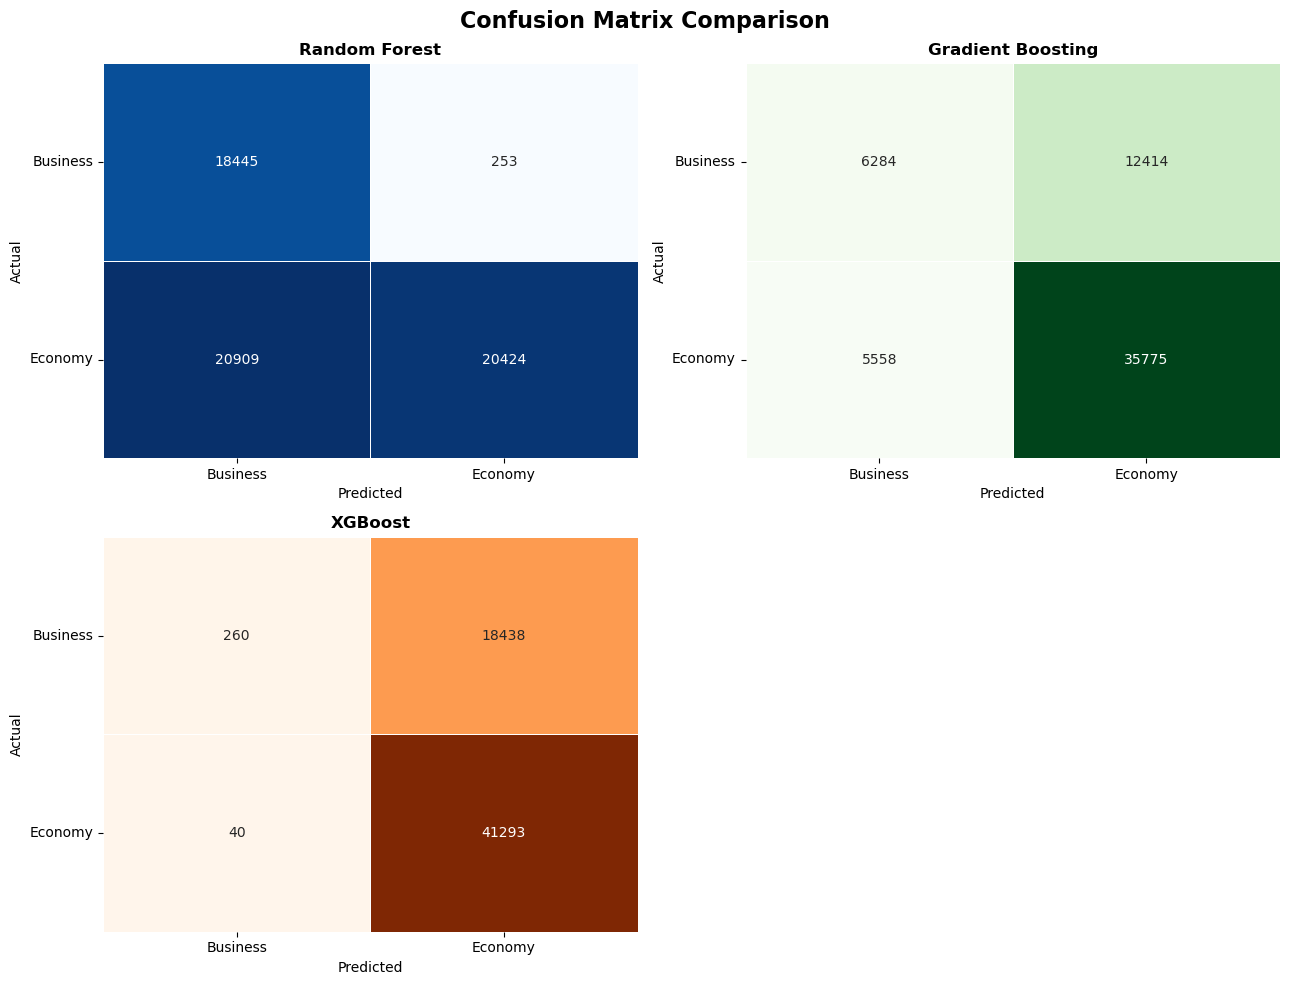

In [28]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boost_model,
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    "XGBoost": xgboost_model
}

cmaps = [
    "Blues",
    "Greens",
    "Oranges",
]

n_models = len(models)
cols = 2
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(13, 5 * rows))
axes = axes.flatten()

for ax, (name, model), cmap in zip(axes, models.items(), cmaps):

    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )

    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Business", "Economy"])
    ax.set_yticklabels(["Business", "Economy"], rotation=0)

for ax in axes[n_models:]:
    fig.delaxes(ax)

plt.suptitle("Confusion Matrix Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

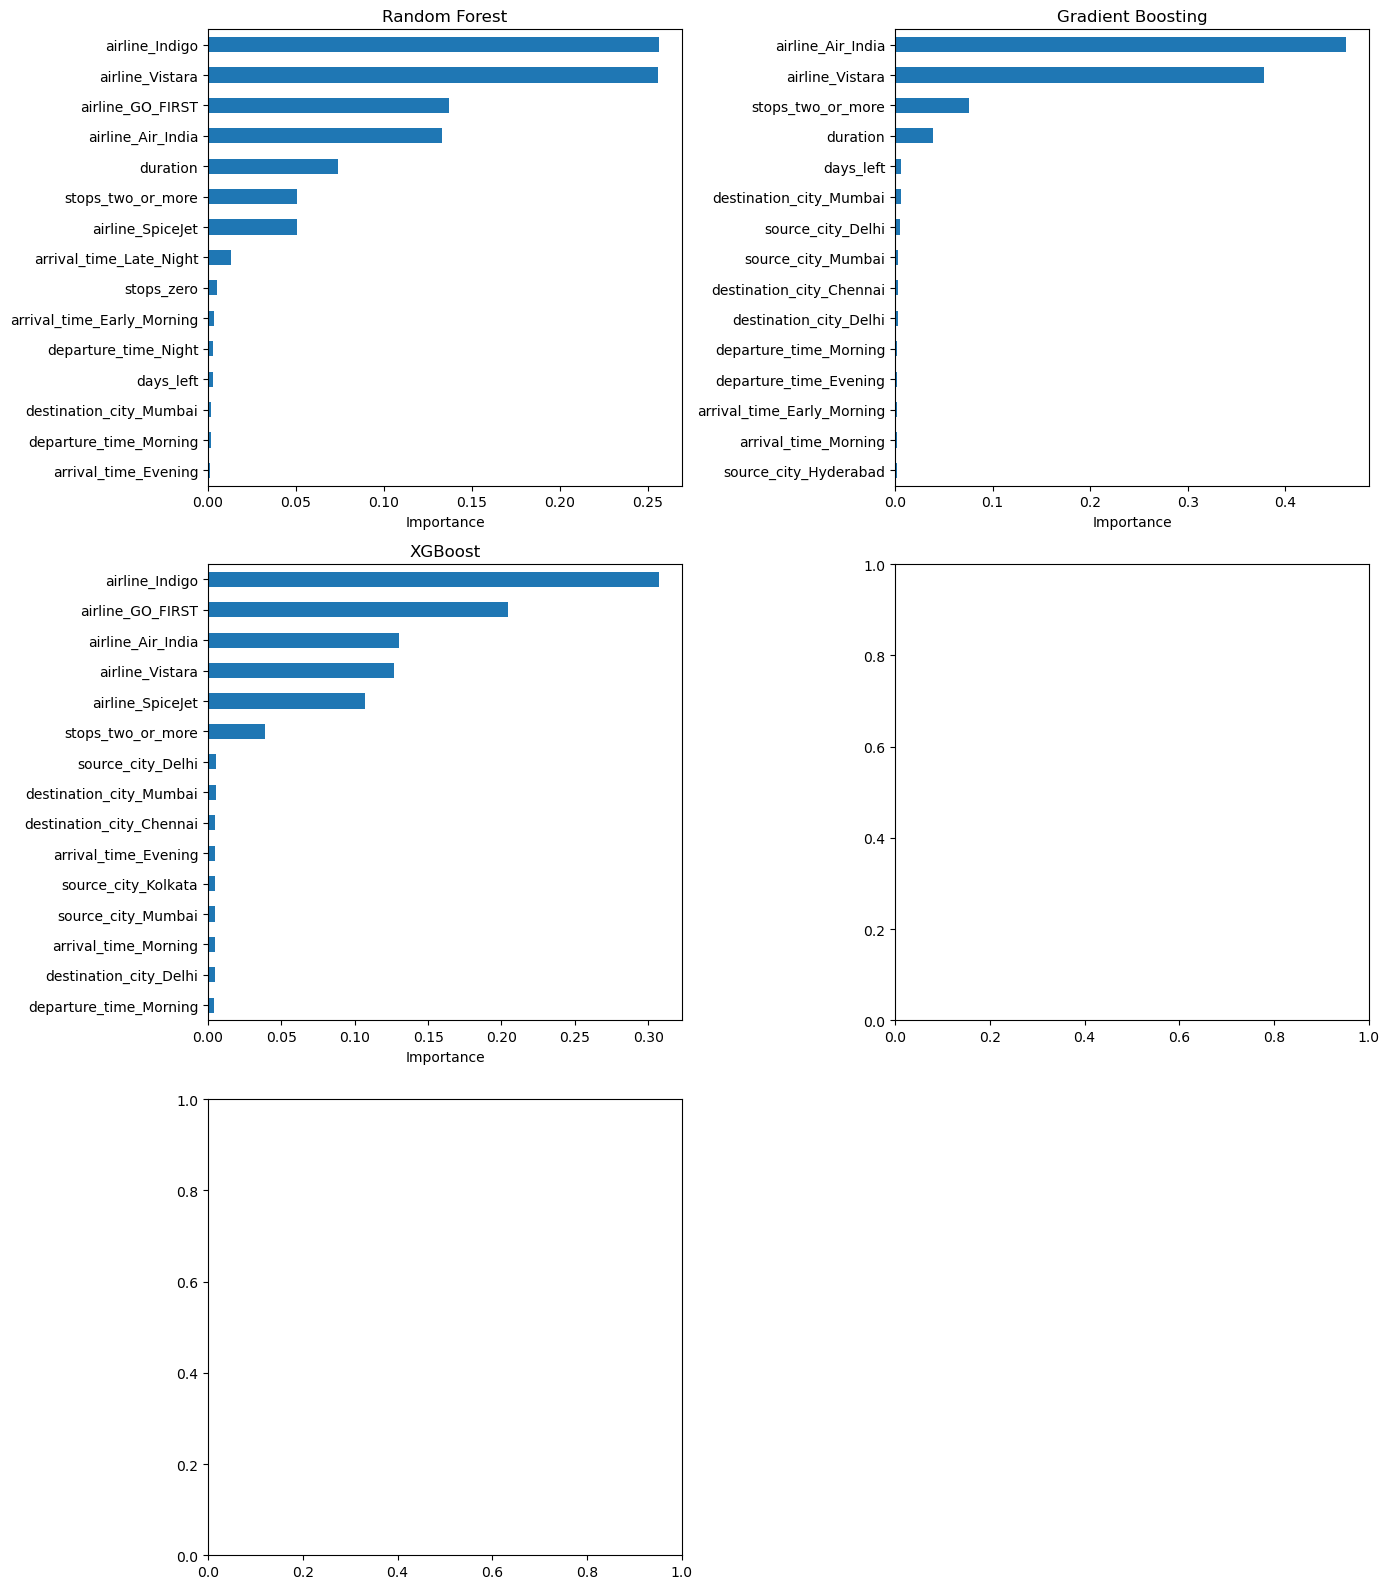

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boost_model,
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    "XGBoost": xgboost_model
}

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):

    importance = pd.Series(
        model.named_steps["model"].feature_importances_,
        index=X_encoded.columns
    ).sort_values(ascending=False).head(15)

    importance.plot.barh(ax=ax)
    ax.set_title(name)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Visualization Analysis: Feature Importance
- **Marking Values:** The longest bars at the top of the chart represent the features that drove the model's decision-making process the most.
- **Correct Interpretation:** If a feature has 0 importance, the tree/forest never used it to make a split. It can be safely dropped from the dataset.
- **How to Interpret:** The X-axis represents the magnitude of the feature's contribution (e.g., Gini impurity reduction) to the final predictions.
- **Common Mistakes:** Assuming a low feature importance means the feature is globally useless. It might just be heavily correlated with a higher-ranking feature that "stole" its importance.

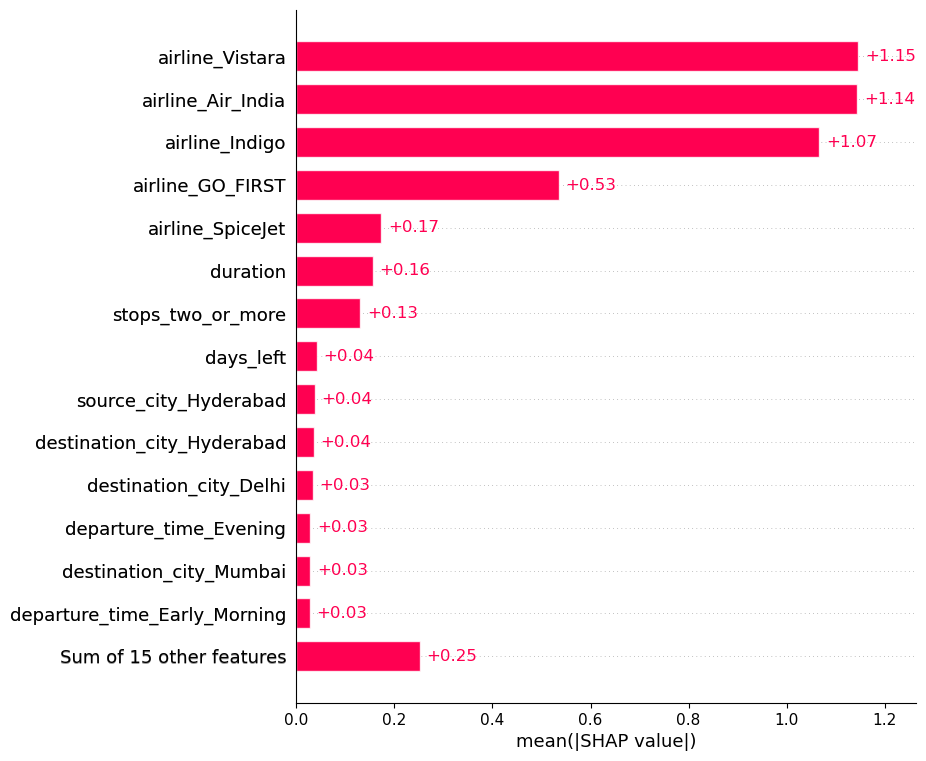

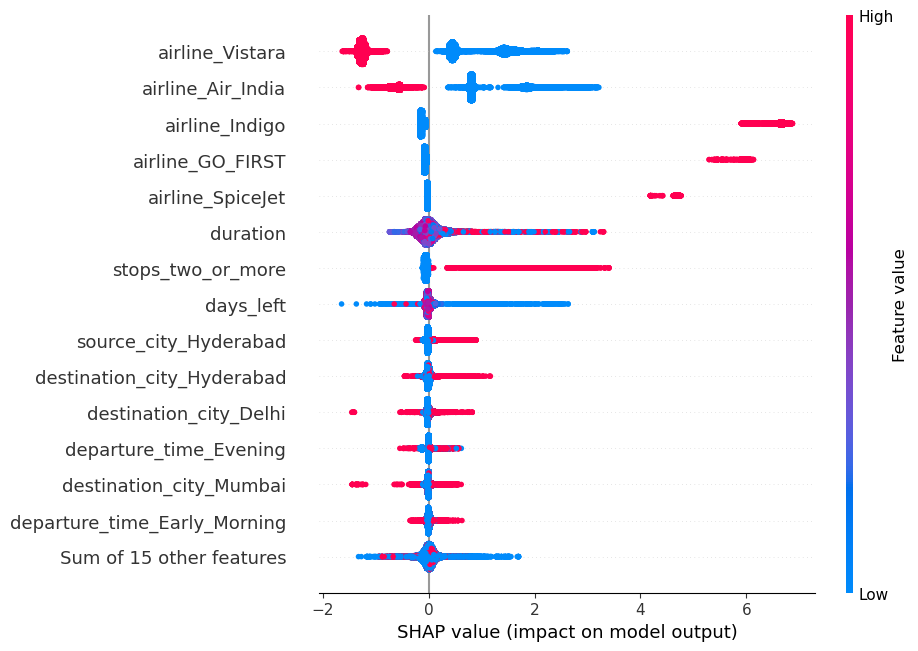

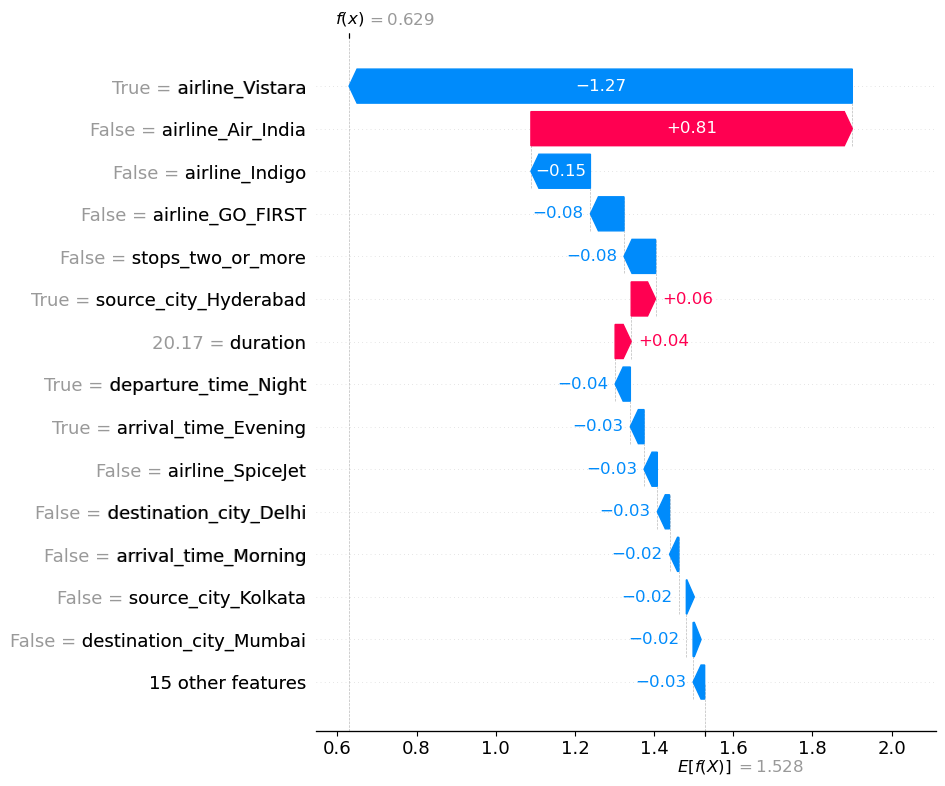

In [30]:
import shap

xgb = xgboost_model.named_steps["model"]

explainer = shap.Explainer(xgb)

shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=15)

shap.plots.beeswarm(shap_values, max_display=15)

shap.plots.waterfall(shap_values[0], max_display=15)

shap.initjs()
shap.plots.force(shap_values[0])


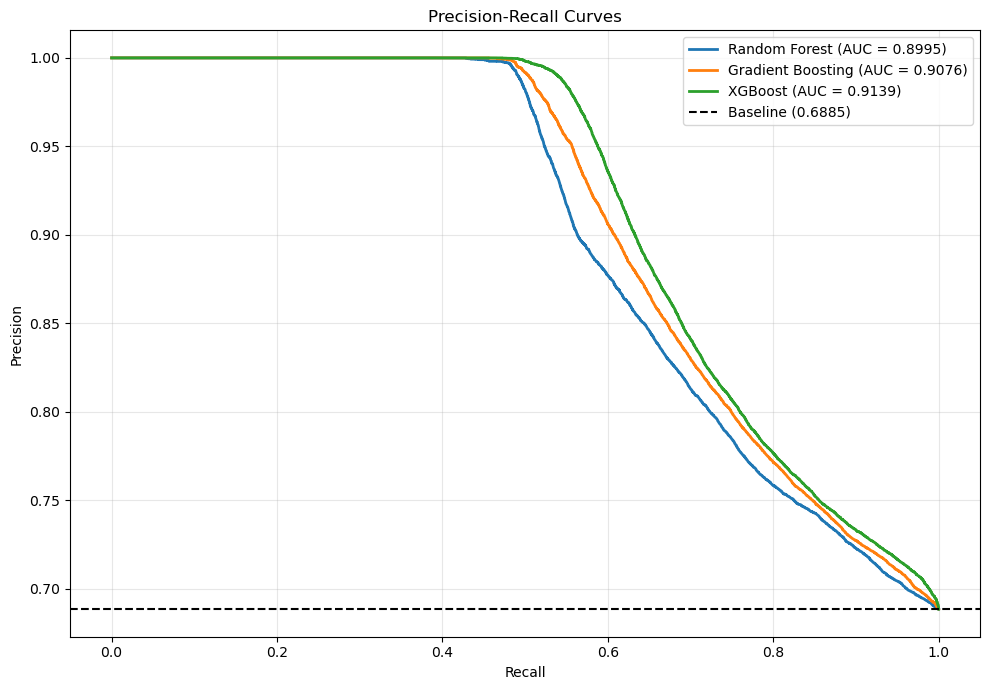

In [32]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boost_model,
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    "XGBoost": xgboost_model
}

y_true = y_test.ravel()

plt.figure(figsize=(10, 7))

for name, model in models.items():

    probs = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(recall, precision)

    plt.plot(
        recall,
        precision,
        lw=2,
        label=f"{name} (AUC = {pr_auc:.4f})"
    )

baseline = y_true.mean()
plt.axhline(
    baseline,
    color="black",
    linestyle="--",
    label=f"Baseline ({baseline:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

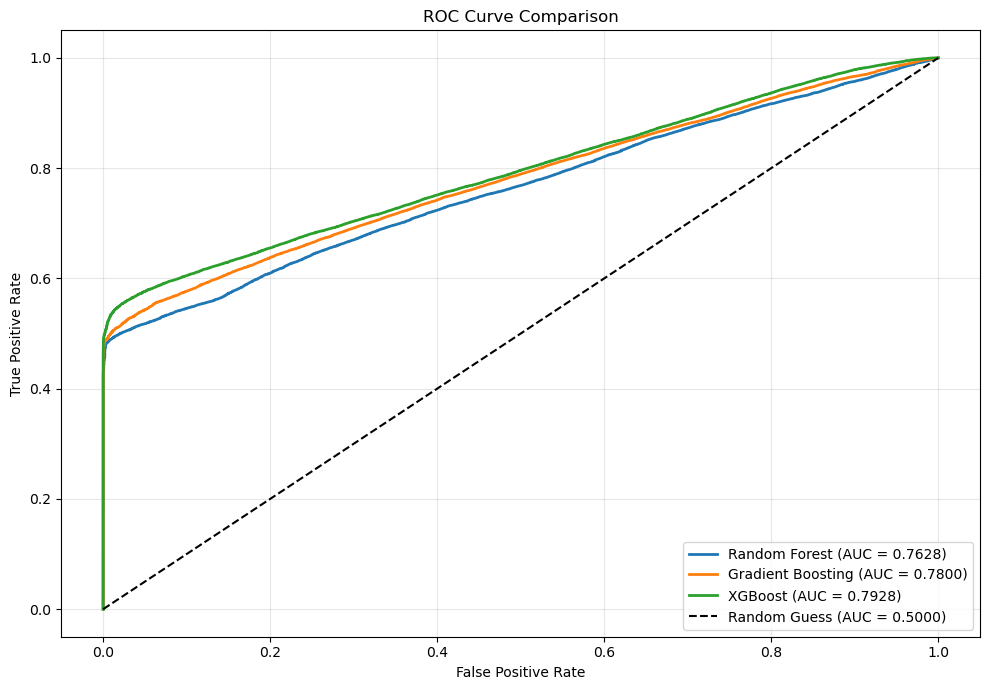

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boost_model,
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    "XGBoost": xgboost_model
}

plt.figure(figsize=(10, 7))

for name, model in models.items():

    probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
    auc_score = roc_auc_score(y_test, probs)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Guess (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

### Conclusion
- **Biggest takeaway:** Gradient Boosting models like XGBoost provide unparalleled accuracy for structured data tasks like dynamic pricing.